## Load Data

In [190]:
folder = "Data/Pipe_Can_717_0/"

In [191]:
import pickle
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import math

In [192]:
resolution = 0
temp = folder.split("_")
if temp[2] == "717":
    resolution = 0.04
    if temp[0].split("/")[1] == "Air":
        threshold = 100000
    else:
        threshold = 0.8e6
else:
    resolution = 0.047
    threshold = 2.0e6
title = f"Measurement in {temp[0].split("/")[1]} using {temp[1]} as target with sensor at {temp[3][-2]}cm offset"
print(resolution)
print(title)

0.04
Measurement in Pipe using Can as target with sensor at 0cm offset


In [193]:
dataLin = []
dataLog = []

with open(folder + 'None.pkl', 'rb') as f:
    fileData = pickle.load(f)

fileData = [val[8] for val in fileData]
fileData = [sum(col)/ len(col) for col in zip(*fileData)]

maxRange = len(fileData) * resolution
x = np.linspace(0, maxRange, len(fileData))

dataLin.append([(32.0/float(len(x))) * (2**(val/512.0)) for val in fileData])
dataLog.append([(val*20.0*math.log10(2.0))/512.0 + 20.0*math.log10(32.0/float(len(x))) for val in fileData])

for i in range(5,205,5):
    with open(folder + f'{i}.pkl', 'rb') as f:
        fileData = pickle.load(f)
    fileData = [val[8] for val in fileData]
    fileData = [sum(col)/ len(col) for col in zip(*fileData)]

    dataLin.append([(32.0/float(len(x))) * (2**(val/512.0)) for val in fileData])
    dataLog.append([(val*20.0*math.log10(2.0))/512.0 + 20.0*math.log10(32.0/float(len(x))) for val in fileData])


In [194]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

In [195]:
measuredPos = []
for i in range(len(dataLin)):
    smoothed = gaussian_filter1d(dataLin[i], sigma=1)
    peaks, properties = find_peaks(smoothed, height=threshold)
    if peaks.size:
        measuredPos.append(x[peaks[0]] * 100.0)
    else:
        print("Not found")
        measuredPos.append(None)

measuredPos = np.array(measuredPos)
actualPos = np.array(range(0,205,5))

Not found
Not found


In [196]:
cleaned = [(x, y) for x, y in zip(actualPos, measuredPos) 
           if x is not None and y is not None]

actual_clean, measured_clean = zip(*cleaned)

m, c = np.polyfit(actual_clean, measured_clean, 1)
lineOBF = m * np.array(actual_clean) + c
lineOBF = m * actualPos + c

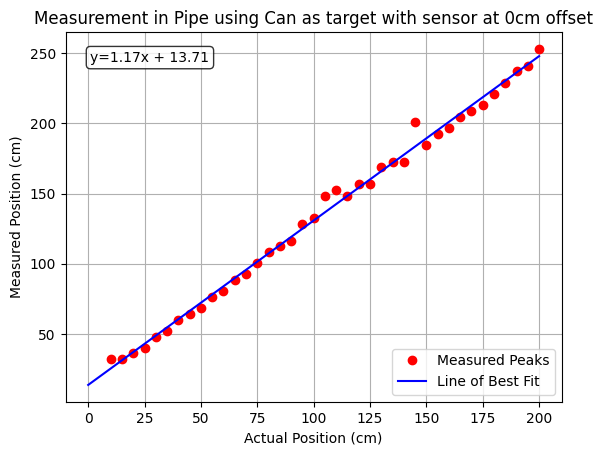

In [197]:
plt.plot(actualPos, measuredPos, "ro", label="Measured Peaks")
plt.plot(actualPos, lineOBF, "b-", label="Line of Best Fit")
plt.xlabel("Actual Position (cm)")
plt.ylabel("Measured Position (cm)")
plt.legend()
plt.text(
    0.05, 0.95, f"y={m:.2f}x + {c:.2f}",
    transform=plt.gca().transAxes,   # use axis coordinates (0–1)
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
plt.grid()
plt.title(title)
plt.show()

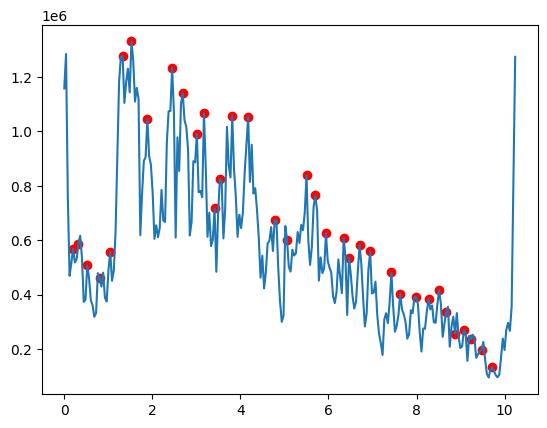

In [198]:
i = 20
smoothed = gaussian_filter1d(dataLin[i], sigma=1)
peaks, properties = find_peaks(smoothed, height=70000)

plt.plot([x[val] for val in peaks], [dataLin[i][val] for val in peaks], "ro")
plt.plot(x, dataLin[i])
plt.show()